In [1]:
import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from importlib.resources import files
from IPython.display import Image
from scipy.spatial.transform import Rotation as R
import imageio.v2 as imageio
import os
import math

In [2]:
epf = [
    ("particle_family", "b"),
    ("particle_tag", "b"),
    ("particle_birth_epoch", "d"),
    ("particle_metallicity", "d"),
]

ds = yt.load('data/output_00273/info_00273.txt', extra_particle_fields=epf)
ad = ds.all_data() 

yt : [INFO     ] 2025-11-17 18:45:25,107 Parameters: current_time              = 0.3604448649237178 Gyr
yt : [INFO     ] 2025-11-17 18:45:25,107 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-11-17 18:45:25,108 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-11-17 18:45:25,109 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-11-17 18:45:25,111 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2025-11-17 18:45:25,112 Parameters: current_redshift          = 12.171087046255657
yt : [INFO     ] 2025-11-17 18:45:25,117 Parameters: omega_lambda              = 0.685000002384186
yt : [INFO     ] 2025-11-17 18:45:25,119 Parameters: omega_matter              = 0.314999997615814
yt : [INFO     ] 2025-11-17 18:45:25,121 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-11-17 18:45:25,123 Parameters: hubble_constant           = 0.674000015258789
yt : [WARNING  ] 2025-11-17 18:45:25,393 This output

In [3]:
cgs_yr = 3.1556926e7  # 1yr (in s)
cgs_pc = 3.08567758e18  # pc (in cm)
h_0 = ds.hubble_constant * 100 # hubble parameter (km/s/Mpc)
h_0_invsec = h_0 * 1e5 / (1e6 * cgs_pc)  # hubble constant h [km/s Mpc-1]->[1/sec]
h_0inv_yr = 1 / h_0_invsec / cgs_yr  # 1/h_0 [yr]
star_age_myr = np.array(ad["star", "particle_birth_epoch"]) * h_0inv_yr / 1e6 + 13787

yt : [INFO     ] 2025-11-17 18:45:26,561 Identified   384/  384 intersecting domains (  385 through hilbert key indexing)


In [4]:
x1 = ad["star", "particle_position_x"].in_units("pc")
y1 = ad["star", "particle_position_y"].in_units("pc")
z1 = ad["star", "particle_position_z"].in_units("pc")

center_pc = (np.mean(x1), np.mean(y1), np.mean(z1))

#convert center_pc to astropy.skycoord
from astropy.coordinates import SkyCoord
from astropy import units as u

coord = SkyCoord(x=np.mean(x1) * u.pc,
                y=np.mean(y1) * u.pc,
                z=np.mean(z1) * u.pc,
                 frame='galactocentric')
coord_icrs = coord.transform_to('icrs')
x2 = x1 - center_pc[0]
y2 = y1 - center_pc[1]
z2 = z1 - center_pc[2]

xyz2 = np.array([(x2[i], y2[i], z2[i]) for i in range(len(x2))])

In [6]:
dist = np.sqrt(x2**2 + y2**2 + z2**2)

#get index of the particle with the maximum distance
max_index = np.argmax(dist)
dist[max_index]

unyt_quantity(4827.51382227, 'pc')

In [7]:
from silmaril import Galaxy

C:\Users\kevin\AppData\Local\Temp\ipykernel_14652\1156516300.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


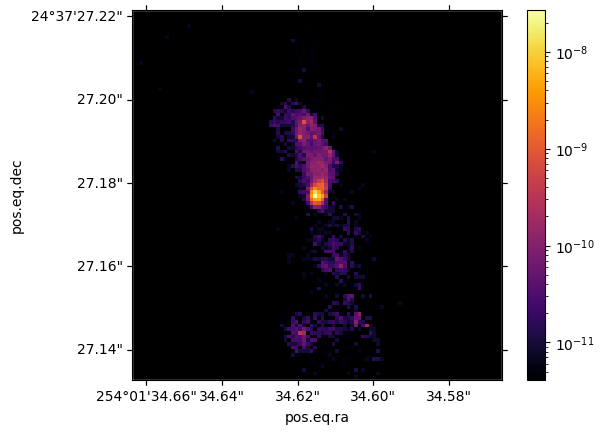

In [8]:
g = Galaxy("output_00273.txt", coord_icrs, ds.current_redshift, dist[max_index].value/30)

fig, ax = g.plot(100)
fig.show()

[215.32209409 216.30476746 216.30476746 ... 152.03806382 152.052546
 164.94939849]
[[ 409.5405513   396.65037123  564.75866567]
 [-130.46410851  137.07137934 -153.63546895]
 [-154.1563539   112.90018201  -95.30068302]
 ...
 [ -31.47434328 -115.29469246  -43.31187849]
 [ -23.64843094 -129.31099461  -28.57702174]
 [3965.5959103  2630.24071355  812.87918485]] pc


TypeError: Elements of range must both have a 'units' attribute. Got [[np.float64(-0.04434327899374453), np.float64(0.04434327899374453)], [np.float64(-0.04434327899374453), np.float64(0.04434327899374453)]]

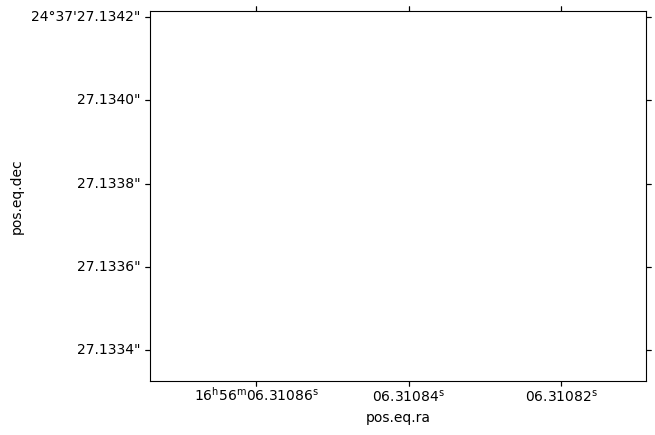

In [ ]:
g = Galaxy("", coord_icrs, ds.current_redshift, dist[max_index].value/30, ds=ds)

fig, ax = g.plot(100)
fig.savefig("out/test_2.png", dpi = 300)